# 📅 Análisis de Meses de Visita — ¿Cuándo vienen y adónde van los viajeros?

**Fuente de datos:** Encuesta de Ocupació Hotelera (EOH) — Instituto Nacional de Estadística (INE)  
---

## 📌 ¿Qué se analiza en este notebook?

Este notebook responde a la pregunta de negocio desde la **dimensión temporal**: ¿cuándo vienen los viajeros y hacia qué destinos se dirigen?

El análisis se divide en los siguientes bloques:

1. **Carga y preparación de datos** — revisión de estructura y calidad de los datasets.
2. **Estacionalidad nacional** — distribución mensual de viajeros a nivel nacional (2021–2025) e identificación de los meses de mayor y menor afluencia.
3. **Evolución interanual por mes** — cómo ha cambiado el volumen de cada mes a lo largo de los cinco años.
4. **Análisis por Comunidades Autónomas** — cuándo son más visitadas las CCAA donde opera StaySpain.
5. **Foco en las ciudades StaySpain** — patrones mensuales en Barcelona, Madrid, Sevilla, Valencia, Málaga, Palma (Mallorca), Girona y Menorca.
6. **Perfil de residencia por mes** — diferencias de estacionalidad entre turistas nacionales e internacionales.
7. **Tendencia de crecimiento interanual** — evolución del volumen de viajeros por ciudad entre 2021 y 2025.
8. **Conclusiones / Hallazgos / Recomendaciones de negocio**

> **Nota de contexto:** Este notebook forma parte de un análisis trifásico. El análisis de *procedencia* (¿de dónde vienen?) y el de *pernoctaciones* (¿cuánto tiempo se quedan?) son tratados por otros analistas del equipo y se integrarán en la puesta en común final.


## 1. Carga y preparación de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

MESES_ES = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
MESES_FULL = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio',
              7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [2]:
# Carga de los datasets relevantes para este análisis
df_com = pd.read_csv('2026_06_15_comunidades_limpio.csv')   # por comunidad autónoma y provincia
df_ciu = pd.read_csv('2026_06_15_ciudades_limpio.csv')       # por ciudad turística

print(f"comunidades: {df_com.shape[0]:,} filas | {df_com.shape[1]} columnas")
print(f"ciudades:    {df_ciu.shape[0]:,} filas | {df_ciu.shape[1]} columnas")


comunidades: 25,200 filas | 13 columnas
ciudades:    33,120 filas | 9 columnas


In [3]:
# Revisión rápida de estructura — mostramos solo filas representativas (sin totales nacionales)
print("=== Estructura del dataset comunidades (filas con datos de CCAA) ===")
display(df_com[df_com['nombre_comunidad'].notna()].head(3))

print("\n=== Estructura del dataset ciudades ===")
display(df_ciu.head(3))


=== Estructura del dataset comunidades (filas con datos de CCAA) ===


,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Viajeros y pernoctaciones,Residencia: Nivel 2,Periodo,Total,cod_comunidad,nombre_comunidad,cod_provincia,nombre_provincia,año,mes
360,Total Nacional,01 Andalucía,NaN,Viajero,NaN,2025M12,1196892.0,1.0,Andalucía,NaN,NaN,2025,12
361,Total Nacional,01 Andalucía,NaN,Viajero,NaN,2025M11,1306347.0,1.0,Andalucía,NaN,NaN,2025,11
362,Total Nacional,01 Andalucía,NaN,Viajero,NaN,2025M10,1903645.0,1.0,Andalucía,NaN,NaN,2025,10



=== Estructura del dataset ciudades ===


,Puntos turísticos,Viajeros y pernoctaciones,Residencia,Periodo,Total,año,mes,cod_postal_ciudad,nombre_ciudad
0,01059 Vitoria-Gasteiz,Viajero,Residentes en España,2025M12,23737.0,2025,12,1059,Vitoria-Gasteiz
1,01059 Vitoria-Gasteiz,Viajero,Residentes en España,2025M11,21544.0,2025,11,1059,Vitoria-Gasteiz
2,01059 Vitoria-Gasteiz,Viajero,Residentes en España,2025M10,24269.0,2025,10,1059,Vitoria-Gasteiz


> **Nota sobre la estructura del dataset `comunidades`:**  
> El dataset tiene una jerarquía territorial de tres niveles: *Total Nacional → Comunidad Autónoma → Provincia*.  
> Las filas del nivel "Total Nacional" no pertenecen a ninguna comunidad autónoma específica, por lo que los campos  
> `nombre_comunidad`, `nombre_provincia`, `cod_comunidad` y `cod_provincia` están vacíos (NaN) en esas filas — esto es **correcto y esperado** por diseño del dataset del INE.  
> A lo largo del notebook filtraremos siempre el nivel jerárquico adecuado para cada análisis.


In [4]:
# Calidad de datos: valores nulos por nivel jerárquico
print("=== Dataset comunidades — nulos por nivel ===")
for nivel, sub in [
    ("Total Nacional", df_com[df_com['nombre_comunidad'].isna()]),
    ("Nivel CCAA",     df_com[df_com['nombre_comunidad'].notna() & df_com['nombre_provincia'].isna()]),
    ("Nivel Provincia",df_com[df_com['nombre_provincia'].notna()])
]:
    print(f"  {nivel}: {len(sub):,} filas — nulos en nombre_comunidad: {sub['nombre_comunidad'].isna().sum()}")

print("\n=== Dataset ciudades — nulos ===")
print(df_ciu.isnull().sum())


=== Dataset comunidades — nulos por nivel ===
  Total Nacional: 360 filas — nulos en nombre_comunidad: 360
  Nivel CCAA: 6,840 filas — nulos en nombre_comunidad: 0
  Nivel Provincia: 18,000 filas — nulos en nombre_comunidad: 0

=== Dataset ciudades — nulos ===
Puntos turísticos               0
Viajeros y pernoctaciones       0
Residencia                      0
Periodo                         0
Total                        7654
año                             0
mes                             0
cod_postal_ciudad               0
nombre_ciudad                   0
dtype: int64


In [5]:
# Rango temporal y variables disponibles
print("=== Años disponibles ===")
print(f"  comunidades: {sorted(df_com['año'].unique())}")
print(f"  ciudades:    {sorted(df_ciu['año'].unique())}")

print("\n=== Variable 'Viajeros y pernoctaciones' — valores únicos ===")
print(f"  comunidades: {df_com['Viajeros y pernoctaciones'].unique().tolist()}")
print(f"  ciudades:    {df_ciu['Viajeros y pernoctaciones'].unique().tolist()}")

print("\n=== Residencia — valores únicos ===")
print(f"  comunidades (Nivel 2): {df_com['Residencia: Nivel 2'].dropna().unique().tolist()}")
print(f"  ciudades:              {df_ciu['Residencia'].unique().tolist()}")


=== Años disponibles ===
  comunidades: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  ciudades:    [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

=== Variable 'Viajeros y pernoctaciones' — valores únicos ===
  comunidades: ['Viajero', 'Pernoctaciones']
  ciudades:    ['Viajero', 'Pernoctaciones']

=== Residencia — valores únicos ===
  comunidades (Nivel 2): ['Residentes en España', 'Residentes en el Extranjero']
  ciudades:              ['Residentes en España', 'Residentes en el Extranjero']


In [6]:
# Preparación: serie nacional de viajeros
# Filtramos nivel 'Total Nacional', sin desglose por CCAA ni por residencia
df_nac = df_com[
    (df_com['nombre_comunidad'].isna()) &
    (df_com['Viajeros y pernoctaciones'] == 'Viajero') &
    (df_com['Residencia: Nivel 2'].isna())
].copy()

print(f"Serie nacional de viajeros: {df_nac.shape[0]} registros | años: {sorted(df_nac['año'].unique())}")


Serie nacional de viajeros: 60 registros | años: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [7]:
# Preparación: ciudades StaySpain
CIUDADES_SS = {
    'Barcelona'            : 'Barcelona',
    'Madrid'               : 'Madrid',
    'Sevilla'              : 'Sevilla',
    'València'             : 'Valencia',
    'Málaga'               : 'Málaga',
    'Palma'                : 'Palma (Mallorca)',
    'Girona'               : 'Girona',
    'Ciutadella de Menorca': 'Menorca',
}

df_ss = df_ciu[df_ciu['nombre_ciudad'].isin(CIUDADES_SS.keys())].copy()
df_ss['ciudad_label'] = df_ss['nombre_ciudad'].map(CIUDADES_SS)
df_ss_viaj = df_ss[df_ss['Viajeros y pernoctaciones'] == 'Viajero'].copy()

print(f"Ciudades StaySpain encontradas: {df_ss['nombre_ciudad'].unique().tolist()}")
print(f"Total filas viajeros (todas las ciudades, todos los años): {df_ss_viaj.shape[0]:,}")

# Diagnóstico de disponibilidad real de datos por ciudad y año
print("\nFilas en el CSV vs. filas con valor numérico real en 'Total':")
resumen_disp = []
for ciudad in sorted(CIUDADES_SS.values()):
    sub = df_ss_viaj[df_ss_viaj['ciudad_label'] == ciudad]
    for anio in sorted(sub['año'].unique()):
        sub_a = sub[sub['año'] == anio]
        filas_csv   = len(sub_a)
        filas_valor = int(sub_a['Total'].notna().sum())
        resumen_disp.append({
            'Ciudad': ciudad, 'Año': anio,
            'Filas en CSV': filas_csv, 'Filas con valor numérico': filas_valor,
        })

disp_df = pd.DataFrame(resumen_disp)
print("\n-- Girona --")
display(disp_df[disp_df['Ciudad']=='Girona'])
print("\n-- Menorca --")
display(disp_df[disp_df['Ciudad']=='Menorca'])

# Ciudades útiles para análisis temporal 2021-2024
ciudades_con_dato_2021 = [c for c in CIUDADES_SS.values()
    if df_ss_viaj[(df_ss_viaj['ciudad_label']==c) & (df_ss_viaj['año']==2021) & df_ss_viaj['Total'].notna()].shape[0] > 0]
ciudades_sin_dato_2021 = [c for c in CIUDADES_SS.values() if c not in ciudades_con_dato_2021]
print(f"\nCiudades con valores numéricos en 2021: {ciudades_con_dato_2021}")
print(f"Ciudades SIN valores numéricos en 2021-2023: {ciudades_sin_dato_2021}")


Ciudades StaySpain encontradas: ['Ciutadella de Menorca', 'Palma', 'Barcelona', 'Girona', 'Madrid', 'Málaga', 'Sevilla', 'València']
Total filas viajeros (todas las ciudades, todos los años): 960

Filas en el CSV vs. filas con valor numérico real en 'Total':

-- Girona --


,Ciudad,Año,Filas en CSV,Filas con valor numérico
5,Girona,2021,24,0
6,Girona,2022,24,0
7,Girona,2023,24,0
8,Girona,2024,24,24
9,Girona,2025,24,24



-- Menorca --


,Ciudad,Año,Filas en CSV,Filas con valor numérico
15,Menorca,2021,24,0
16,Menorca,2022,24,0
17,Menorca,2023,24,0
18,Menorca,2024,24,16
19,Menorca,2025,24,14



Ciudades con valores numéricos en 2021: ['Barcelona', 'Madrid', 'Sevilla', 'Valencia', 'Málaga', 'Palma (Mallorca)']
Ciudades SIN valores numéricos en 2021-2023: ['Girona', 'Menorca']


> **Nota sobre disponibilidad de datos — Girona y Menorca:**  
> El CSV contiene filas para Girona y Menorca desde 2021, pero los campos `Total` están vacíos (NaN) en los años 2021, 2022 y 2023. Esto significa que el INE **no publicó datos** para estas dos ciudades en ese período — las filas existen en el dataset como marcadores de posición pero sin valor numérico.  
> Los primeros datos reales disponibles son: **Girona desde enero de 2024** y **Menorca desde marzo de 2024** (Menorca además no tiene datos en los meses de invierno, reflejo del cierre de establecimientos).  
> En todos los análisis del notebook se trabaja únicamente con los valores numéricos disponibles; los NaN se excluyen automáticamente de los cálculos.


---
## 2. Estacionalidad nacional — ¿Cuáles son los meses de mayor afluencia?

Analizamos la distribución mensual de viajeros a nivel nacional, sumando los cinco años (2021–2025).  
Esto nos da el **perfil estacional medio** del turismo hotelero en España.


In [8]:
estac_nac = (df_nac.groupby('mes')['Total'].sum()
             .reset_index().sort_values('mes'))
estac_nac['mes_label'] = estac_nac['mes'].map(MESES_ES)
estac_nac['pct'] = estac_nac['Total'] / estac_nac['Total'].sum() * 100

tabla_estac = estac_nac[['mes_label','Total','pct']].copy()
tabla_estac.columns = ['Mes', 'Viajeros acumulados (2021-2025)', '% del total anual']
tabla_estac['Viajeros acumulados (2021-2025)'] = tabla_estac['Viajeros acumulados (2021-2025)'].map('{:,.0f}'.format)
tabla_estac['% del total anual'] = tabla_estac['% del total anual'].map('{:.1f}%'.format)
display(tabla_estac.reset_index(drop=True))


,Mes,Viajeros acumulados (2021-2025),% del total anual
0,Ene,"21,698,050",4.3%
1,Feb,"25,335,159",5.0%
2,Mar,"31,334,739",6.1%
3,Abr,"39,910,860",7.8%
4,May,"47,476,879",9.3%
5,Jun,"52,323,913",10.3%
6,Jul,"59,254,512",11.6%
7,Ago,"64,016,028",12.5%
8,Sep,"54,738,713",10.7%
9,Oct,"50,064,535",9.8%


**Interpretación técnica:** La tabla muestra la distribución acumulada de viajeros por mes durante los cinco años analizados. Los valores más altos se concentran entre julio y octubre (con agosto y octubre rozando el 10% mensual cada uno), mientras que enero y febrero son los meses de menor actividad (en torno al 5-6% cada uno). Ningún mes concentra por sí solo más del 11% del total, lo que indica que la estacionalidad, si bien marcada, no es extrema a nivel nacional.

**Interpretación de negocio:** La demanda turística hotelera en España se concentra principalmente en el tercer trimestre del año. Para StaySpain esto implica que la mayor presión de ocupación y competencia entre alojamientos ocurre en verano. Los meses de enero y febrero representan la menor demanda del año —una oportunidad para diseñar ofertas específicas de turismo urbano, cultural o de negocios que permitan reducir la dependencia del verano.


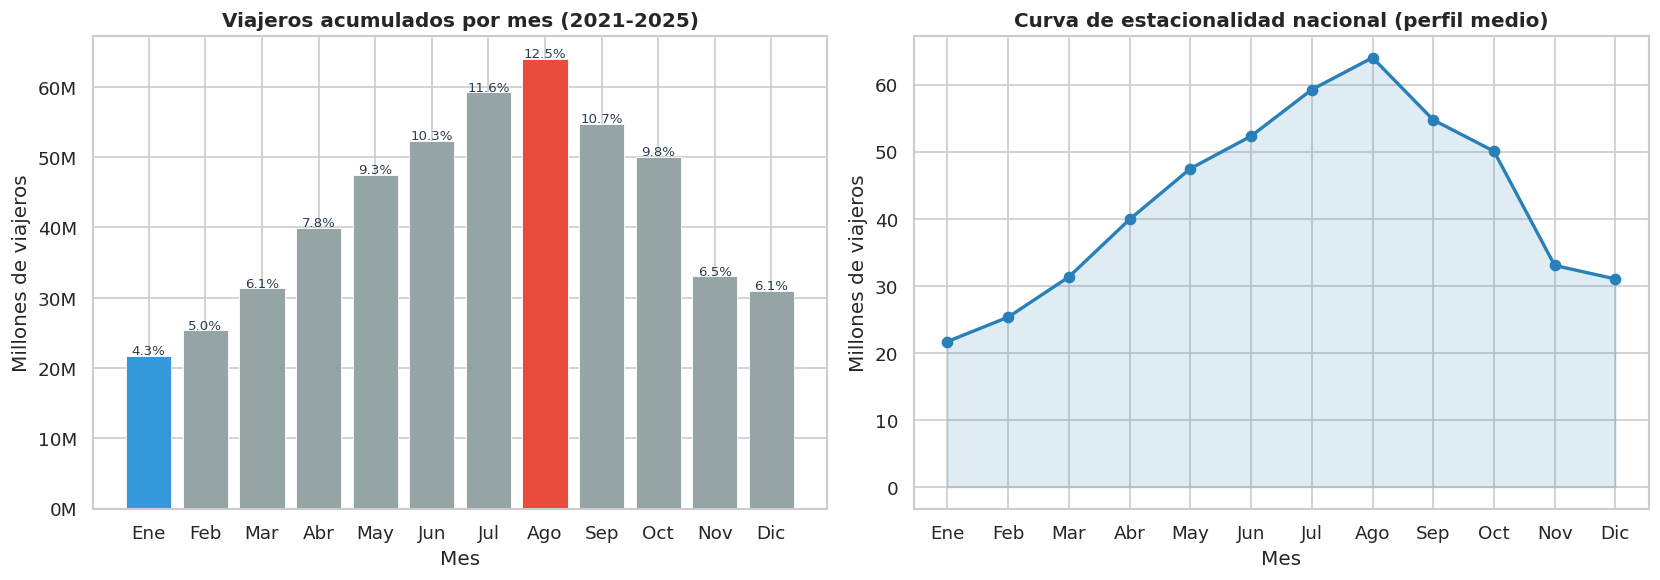

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ['#e74c3c' if v == estac_nac['Total'].max() else
           ('#3498db' if v == estac_nac['Total'].min() else '#95a5a6')
           for v in estac_nac['Total']]

# Barras
axes[0].bar(estac_nac['mes_label'], estac_nac['Total']/1e6,
            color=colores, edgecolor='white', linewidth=0.5)
axes[0].set_title('Viajeros acumulados por mes (2021-2025)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Millones de viajeros')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fM'))
for i, (v, pct) in enumerate(zip(estac_nac['Total'], estac_nac['pct'])):
    axes[0].text(i, v/1e6 + 0.2, f'{pct:.1f}%', ha='center', fontsize=8, color='#2c3e50')

# Curva de área
axes[1].plot(estac_nac['mes_label'], estac_nac['Total']/1e6,
             marker='o', color='#2980b9', linewidth=2)
axes[1].fill_between(range(12), estac_nac['Total']/1e6, alpha=0.15, color='#2980b9')
axes[1].set_title('Curva de estacionalidad nacional (perfil medio)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Millones de viajeros')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(estac_nac['mes_label'])

plt.tight_layout()
plt.savefig('fig1_estacionalidad_nacional.png', bbox_inches='tight')
plt.show()


**Interpretación técnica:** El gráfico de barras resalta en rojo el mes de mayor volumen (agosto) y en azul el de menor (enero). La curva de área muestra la forma de la estacionalidad nacional: una subida progresiva desde enero hasta agosto-octubre, seguida de una bajada hacia fin de año. El perfil es relativamente suave: no hay un único pico extremo sino una meseta estival sostenida (junio–octubre).

**Interpretación de negocio:** La estacionalidad nacional no es explosiva pero sí constante. StaySpain tiene un período de alta demanda de al menos cinco meses (junio–octubre), lo que facilita la planificación operativa. La clave está en aprovechar esos meses con estrategias de precio dinámico y en activar propuestas diferenciadas durante los meses de menor demanda (enero–marzo) para mantener la ocupación.


---
## 3. Evolución interanual por mes — ¿Cómo ha cambiado el patrón temporal entre 2021 y 2025?

Comparamos el perfil mensual de cada año para identificar la recuperación post-COVID y las tendencias más recientes.


In [10]:
pivot_anual = (df_nac.groupby(['año','mes'])['Total'].sum()
               .reset_index()
               .pivot(index='mes', columns='año', values='Total'))
pivot_anual.index = [MESES_ES[m] for m in pivot_anual.index]

tabla_pivot = pivot_anual.copy()
for col in tabla_pivot.columns:
    tabla_pivot[col] = tabla_pivot[col].map(lambda x: f'{x/1e6:.2f}M' if pd.notna(x) else '-')
print("Viajeros por mes y año (millones):")
display(tabla_pivot)


Viajeros por mes y año (millones):


año,2021,2022,2023,2024,2025
Ene,1.12M,3.77M,5.37M,5.66M,5.77M
Feb,1.18M,5.13M,5.97M,6.51M,6.54M
Mar,1.77M,6.06M,7.36M,8.43M,7.71M
Abr,1.96M,8.69M,9.83M,9.39M,10.05M
May,3.40M,9.92M,10.58M,11.77M,11.80M
Jun,5.68M,10.99M,11.54M,11.87M,12.26M
Jul,8.54M,12.29M,12.68M,12.69M,13.04M
Ago,10.41M,12.89M,13.27M,13.62M,13.83M
Sep,8.26M,11.05M,11.63M,11.75M,12.05M
Oct,8.13M,9.74M,10.39M,10.76M,11.04M


**Interpretación técnica:** La tabla muestra el volumen de viajeros en millones para cada combinación mes-año. Los valores de 2021 son claramente inferiores al resto, reflejo de las restricciones post-pandemia que aún estaban vigentes ese año. A partir de 2022 se observa una recuperación progresiva en todos los meses, con 2024 y 2025 alcanzando los niveles más altos del período.

**Interpretación de negocio:** El sector turístico hotelero completó su recuperación post-COVID en 2022-2023 y ha mantenido un crecimiento sostenido. Esta tendencia positiva refuerza la apuesta de StaySpain por ampliar su portfolio: el mercado está en expansión. Cabe destacar que los meses de primavera (abril, mayo) y otoño (octubre) son los que muestran crecimientos más pronunciados entre 2022 y 2025, lo que indica una tendencia a distribuir el flujo turístico más allá del verano estricto.


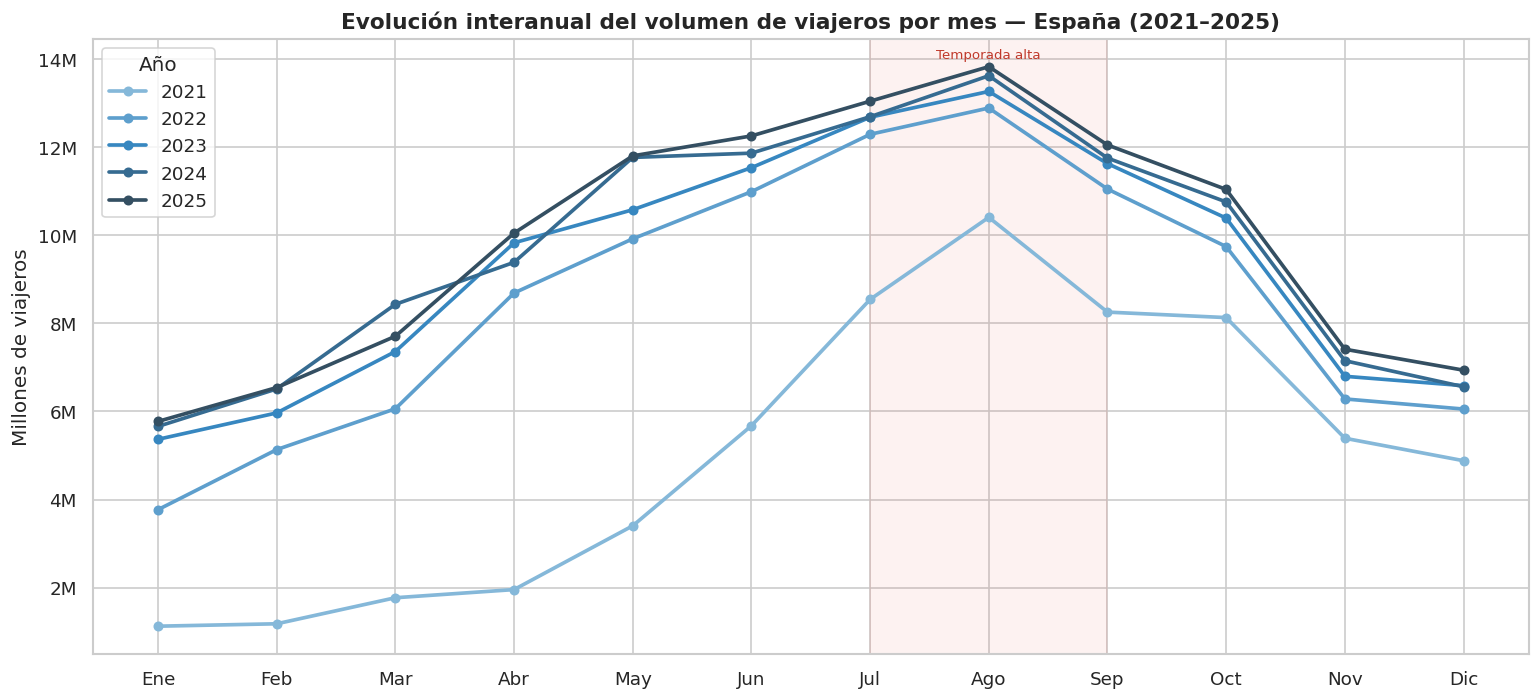

In [11]:
palette = sns.color_palette('Blues_d', n_colors=5)

fig, ax = plt.subplots(figsize=(13, 6))
for i, año in enumerate(sorted(pivot_anual.columns)):
    ax.plot(range(12), pivot_anual[año]/1e6, marker='o', label=str(año),
            color=palette[i], linewidth=2.2, markersize=5)

ax.set_xticks(range(12))
ax.set_xticklabels(list(MESES_ES.values()))
ax.set_title('Evolución interanual del volumen de viajeros por mes — España (2021–2025)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Millones de viajeros')
ax.legend(title='Año', loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fM'))
ax.axvspan(6, 8, alpha=0.07, color='#e74c3c')
ax.text(7, ax.get_ylim()[1]*0.97, 'Temporada alta', ha='center', fontsize=8, color='#c0392b')

plt.tight_layout()
plt.savefig('fig2_evolucion_interanual.png', bbox_inches='tight')
plt.show()


**Interpretación técnica:** Las curvas de tonos más oscuros (años más recientes) se sitúan por encima de las más claras en prácticamente todos los meses, confirmando el crecimiento sostenido. La banda sombreada indica la temporada alta (julio–septiembre). Se aprecia además que las curvas de 2024 y 2025 se aproximan entre sí, especialmente en los meses de mayor demanda, lo que puede indicar que el mercado de verano está alcanzando su techo de capacidad hotelera.

**Interpretación de negocio:** Si la demanda estival ya no puede crecer mucho más (por límite de capacidad de plazas hoteleras), el crecimiento futuro del sector vendrá de los meses de primavera y otoño. StaySpain debería considerar reforzar su oferta y visibilidad especialmente en esos períodos, que muestran mayor margen de crecimiento y menor saturación que el verano.


---
## 4. Estacionalidad por Comunidad Autónoma — ¿Adónde van los viajeros y cuándo?

Analizamos el patrón mensual de las cinco Comunidades Autónomas donde StaySpain está presente:  
**Cataluña, Madrid, Andalucía, Comunitat Valenciana e Illes Balears.**


In [12]:
CCAA_SS = ['Cataluña', 'Madrid, Comunidad de', 'Andalucía',
           'Comunitat Valenciana', 'Balears, Illes']
CCAA_LABEL = {
    'Cataluña': 'Cataluña',
    'Madrid, Comunidad de': 'Madrid',
    'Andalucía': 'Andalucía',
    'Comunitat Valenciana': 'C. Valenciana',
    'Balears, Illes': 'Illes Balears',
}

# Nivel CCAA: nombre_provincia es NaN, y sin desglose de residencia
df_ccaa = df_com[
    (df_com['nombre_comunidad'].isin(CCAA_SS)) &
    (df_com['nombre_provincia'].isna()) &
    (df_com['Viajeros y pernoctaciones'] == 'Viajero') &
    (df_com['Residencia: Nivel 2'].isna())
].copy()
df_ccaa['ccaa_label'] = df_ccaa['nombre_comunidad'].map(CCAA_LABEL)

# Perfil mensual: media de los años disponibles
perfil_ccaa = df_ccaa.groupby(['ccaa_label','mes'])['Total'].mean().reset_index()

# Tabla resumen: mes pico, mes valle y ratio de estacionalidad
resumen_ccaa = []
for ccaa, grp in perfil_ccaa.groupby('ccaa_label'):
    grp = grp.sort_values('mes')
    idx_max = grp['Total'].idxmax()
    idx_min = grp['Total'].idxmin()
    ratio = grp.loc[idx_max,'Total'] / grp.loc[idx_min,'Total']
    resumen_ccaa.append({
        'Comunidad': ccaa,
        'Mes pico': MESES_FULL[grp.loc[idx_max,'mes']],
        'Viajeros pico (media)': f"{grp.loc[idx_max,'Total']/1e6:.2f} M",
        'Mes valle': MESES_FULL[grp.loc[idx_min,'mes']],
        'Viajeros valle (media)': f"{grp.loc[idx_min,'Total']/1e6:.2f} M",
        'Ratio pico/valle': f"{ratio:.1f}x",
    })
df_res_ccaa = pd.DataFrame(resumen_ccaa).sort_values('Ratio pico/valle', ascending=False)
display(df_res_ccaa.reset_index(drop=True))


,Comunidad,Mes pico,Viajeros pico (media),Mes valle,Viajeros valle (media),Ratio pico/valle
0,Illes Balears,Agosto,1.85 M,Enero,0.05 M,34.2x
1,Cataluña,Agosto,2.47 M,Enero,0.77 M,3.2x
2,C. Valenciana,Agosto,1.11 M,Enero,0.37 M,3.0x
3,Andalucía,Agosto,2.17 M,Enero,0.78 M,2.8x
4,Madrid,Octubre,1.12 M,Enero,0.70 M,1.6x


**Interpretación técnica:** La tabla muestra que cuatro de las cinco comunidades tienen agosto como mes pico y enero como mes valle. La diferencia clave entre ellas **no está en qué mes es el pico o el valle, sino en la magnitud de la diferencia** entre ambos, medida por el ratio pico/valle:

- **Illes Balears** tiene un ratio de **34x**: en agosto recibe de media 1,85 millones de viajeros, mientras que en enero apenas llega a 50.000. Esto refleja una estacionalidad extrema, propia de un destino de turismo de sol y playa altamente dependiente del verano.
- **C. Valenciana** y **Cataluña** tienen ratios de 3,0x y 3,2x respectivamente: concentración veraniega clara, pero con un nivel de actividad notable durante el resto del año.
- **Andalucía** (2,8x) muestra una distribución más extendida: la primavera y el otoño sostienen volúmenes muy cercanos al verano.
- **Madrid** es la comunidad menos estacional con un ratio de **1,6x**: su pico (octubre, 1,12 M) es solo 1,6 veces mayor que su valle (enero, 0,70 M), siendo el único destino cuyo pico se sitúa en otoño en lugar de agosto.

**Interpretación de negocio:** El ratio pico/valle es el indicador más relevante para la gestión de alojamientos. Cuanto mayor es el ratio, más crítica es la gestión de precios en temporada alta y más urgente la búsqueda de demanda en temporada baja. Las Illes Balears requieren una estrategia de revenue management intensiva en verano y acciones de activación invernal; Madrid permite una estrategia más estable y continua a lo largo del año.


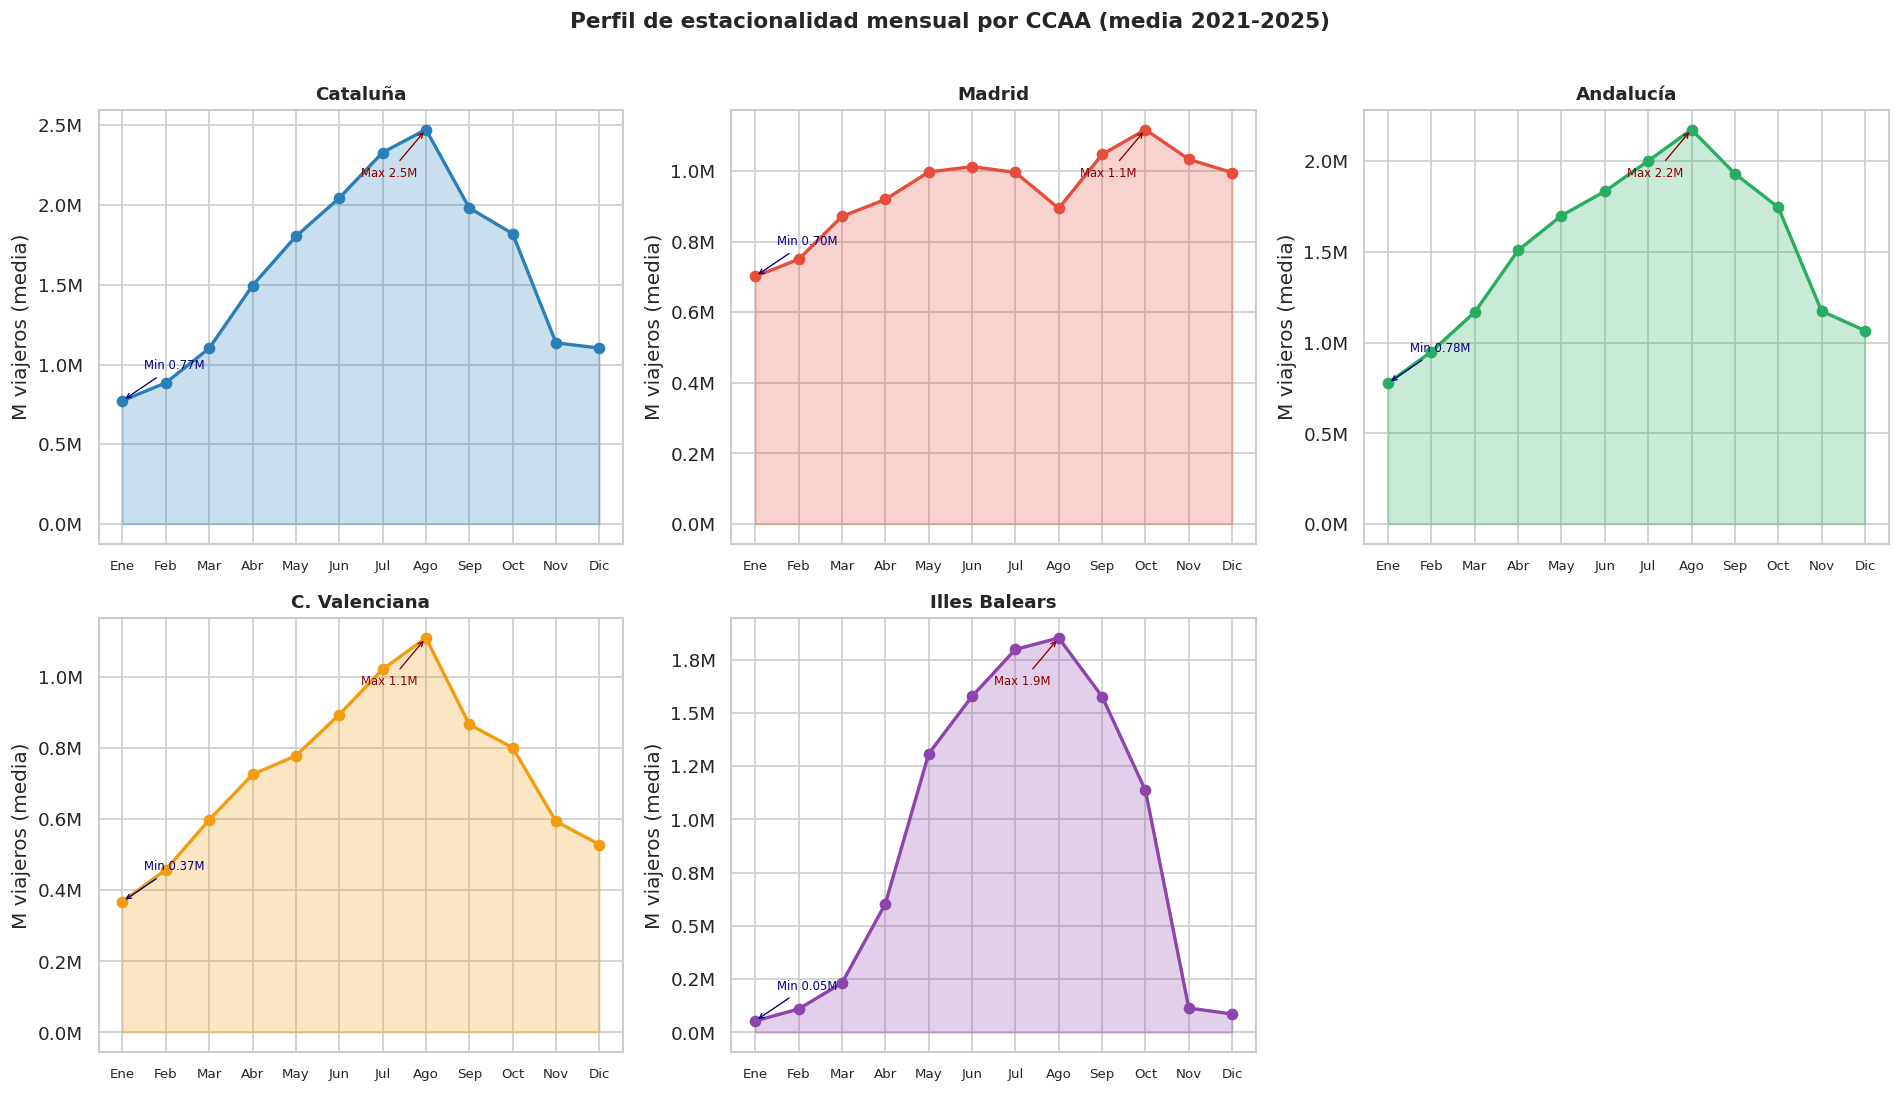

In [13]:
CCAA_ORDEN = ['Cataluna', 'Madrid', 'Andalucia', 'C. Valenciana', 'Illes Balears']
CCAA_ORDEN_LABELS = {
    'Cataluna': 'Cataluña',
    'Madrid': 'Madrid',
    'Andalucia': 'Andalucía',
    'C. Valenciana': 'C. Valenciana',
    'Illes Balears': 'Illes Balears',
}
# Re-map labels to ascii keys for indexing
perfil_ccaa['ccaa_key'] = perfil_ccaa['ccaa_label'].map({
    'Cataluña': 'Cataluna',
    'Madrid': 'Madrid',
    'Andalucía': 'Andalucia',
    'C. Valenciana': 'C. Valenciana',
    'Illes Balears': 'Illes Balears',
})

colors_ccaa = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12', '#8e44ad']

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flatten()

for i, (ccaa_key, color) in enumerate(zip(CCAA_ORDEN, colors_ccaa)):
    ax = axes[i]
    ccaa_label_val = CCAA_ORDEN_LABELS[ccaa_key]
    grp = perfil_ccaa[perfil_ccaa['ccaa_label']==ccaa_label_val].sort_values('mes').copy()
    ax.fill_between(range(12), grp['Total']/1e6, alpha=0.25, color=color)
    ax.plot(range(12), grp['Total']/1e6, marker='o', color=color, linewidth=2)
    ax.set_xticks(range(12))
    ax.set_xticklabels(list(MESES_ES.values()), fontsize=8)
    ax.set_title(ccaa_label_val, fontweight='bold', fontsize=11)
    ax.set_ylabel('M viajeros (media)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fM'))
    # Anotar pico y valle
    idx_max = grp['Total'].idxmax()
    idx_min = grp['Total'].idxmin()
    pos_max = grp['mes'].tolist().index(grp.loc[idx_max,'mes'])
    pos_min = grp['mes'].tolist().index(grp.loc[idx_min,'mes'])
    val_max = grp.loc[idx_max,'Total']/1e6
    val_min = grp.loc[idx_min,'Total']/1e6
    lbl_max = "Max " + "{:.1f}M".format(val_max)
    lbl_min = "Min " + "{:.2f}M".format(val_min)
    ax.annotate(lbl_max,
                xy=(pos_max, val_max),
                xytext=(pos_max-1.5, val_max*0.88),
                fontsize=7, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))
    ax.annotate(lbl_min,
                xy=(pos_min, val_min),
                xytext=(pos_min+0.5, val_min + grp['Total'].max()/1e6*0.08),
                fontsize=7, color='navy',
                arrowprops=dict(arrowstyle='->', color='navy', lw=0.8))

axes[-1].set_visible(False)
fig.suptitle('Perfil de estacionalidad mensual por CCAA (media 2021-2025)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_estacionalidad_ccaa.png', bbox_inches='tight')
plt.show()


**Interpretación técnica:** Los gráficos de área permiten comparar la forma de la curva estacional de cada comunidad. Las anotaciones indican el valor máximo y mínimo de la serie.

**Interpretación de negocio:**
- **Cataluña** muestra una curva amplia con pico en agosto (2,47 M) y niveles altos también en julio, septiembre y octubre. La temporada activa se extiende prácticamente de abril a octubre, lo que facilita una operativa sostenida durante siete meses al año.
- **Madrid** es la comunidad con la curva más plana de las cinco: la diferencia entre el mejor mes (octubre, 1,12 M) y el peor (enero, 0,70 M) es la más pequeña. Esto la convierte en el destino más predecible y estable para StaySpain.
- **Andalucía** presenta una meseta amplia de primavera a otoño (marzo–octubre), con valores superiores al millón de viajeros en todos esos meses. Es el destino que mejor equilibra temporada alta y media.
- **C. Valenciana** tiene un perfil similar a Andalucía pero con volúmenes menores: pico claro en agosto (1,11 M) y niveles moderados en primavera y otoño.
- **Illes Balears** muestra la curva más pronunciada de todas: prácticamente plana en invierno (0,05-0,11 M en enero-febrero) y con un pico muy marcado en julio-agosto (1,80-1,85 M). La temporada activa se concentra en tan solo cinco meses (mayo–septiembre), lo que implica una presión operativa muy intensa en ese período y una capacidad ociosa muy alta el resto del año.


---
## 5. Foco en ciudades StaySpain — ¿Cuándo vienen los viajeros a cada ciudad?

Analizamos el patrón mensual específico de las 8 ciudades donde StaySpain opera.  
Los perfiles se calculan como la **media mensual de los años con datos válidos** por ciudad:  
Girona y Menorca disponen de valores numéricos solo desde 2024; el resto desde 2021.  
(Ver diagnóstico en la Sección 1 — *Preparación: ciudades StaySpain*.)


In [14]:
perfil_ciu = (df_ss_viaj.groupby(['ciudad_label','mes'])['Total']
              .mean().reset_index())
perfil_ciu['mes_label'] = perfil_ciu['mes'].map(MESES_ES)

# Tabla: mes pico, mes valle, ratio de estacionalidad
CIUDADES_ORDEN = ['Barcelona','Girona','Madrid','Sevilla','Málaga',
                  'Valencia','Palma (Mallorca)','Menorca']

resumen_ciu = []
for ciudad in CIUDADES_ORDEN:
    grp = perfil_ciu[perfil_ciu['ciudad_label']==ciudad].copy()
    if grp.empty:
        continue
    grp_valid = grp.dropna(subset=['Total'])
    idx_max = grp_valid['Total'].idxmax()
    idx_min = grp_valid['Total'].idxmin()
    ratio = grp_valid.loc[idx_max,'Total'] / grp_valid.loc[idx_min,'Total']
    resumen_ciu.append({
        'Ciudad': ciudad,
        'Mes pico': MESES_FULL[grp_valid.loc[idx_max,'mes']],
        'Viajeros pico (media)': f"{grp_valid.loc[idx_max,'Total']:,.0f}",
        'Mes valle': MESES_FULL[grp_valid.loc[idx_min,'mes']],
        'Viajeros valle (media)': f"{grp_valid.loc[idx_min,'Total']:,.0f}",
        'Ratio pico/valle': f"{ratio:.1f}x",
    })
df_res_ciu = pd.DataFrame(resumen_ciu)
display(df_res_ciu.reset_index(drop=True))


,Ciudad,Mes pico,Viajeros pico (media),Mes valle,Viajeros valle (media),Ratio pico/valle
0,Barcelona,Octubre,"360,585",Enero,"199,930",1.8x
1,Girona,Agosto,"18,676",Diciembre,"10,026",1.9x
2,Madrid,Octubre,"432,932",Enero,"274,844",1.6x
3,Sevilla,Octubre,"134,718",Enero,"82,934",1.6x
4,Málaga,Julio,"68,457",Enero,"40,448",1.7x
5,Valencia,Agosto,"93,060",Enero,"55,704",1.7x
6,Palma (Mallorca),Julio,"155,653",Enero,"19,950",7.8x
7,Menorca,Agosto,"37,730",Marzo,540,69.8x


**Interpretación técnica:** La tabla muestra el mes de mayor y menor afluencia media para cada ciudad, y el ratio pico/valle que mide la intensidad de la estacionalidad. Se observa una enorme variabilidad entre ciudades: el ratio va desde **1,6x** (Madrid y Sevilla, los menos estacionales) hasta **69,8x** (Menorca, altamente estacional).

> **Nota:** Menorca presenta un ratio extremo (69,8x) porque su mes más bajo (marzo, ~540 viajeros) corresponde a períodos de muy baja actividad turística con pocos establecimientos abiertos, en contraste con agosto (~37.700). Este ratio refleja fielmente la estacionalidad real del destino.

**Interpretación de negocio:** Madrid y Sevilla comparten el ratio más bajo (1,6x), lo que las convierte en los destinos más equilibrados del portfolio StaySpain —ambos pueden sostener una ocupación razonablemente alta durante todo el año—. Palma (7,8x) ya requiere una gestión más activa de la temporada baja. Menorca (69,8x) y, en menor medida, Girona (1,9x con datos desde 2024) son los destinos donde la estrategia de precios en temporada alta es más determinante para la rentabilidad anual.


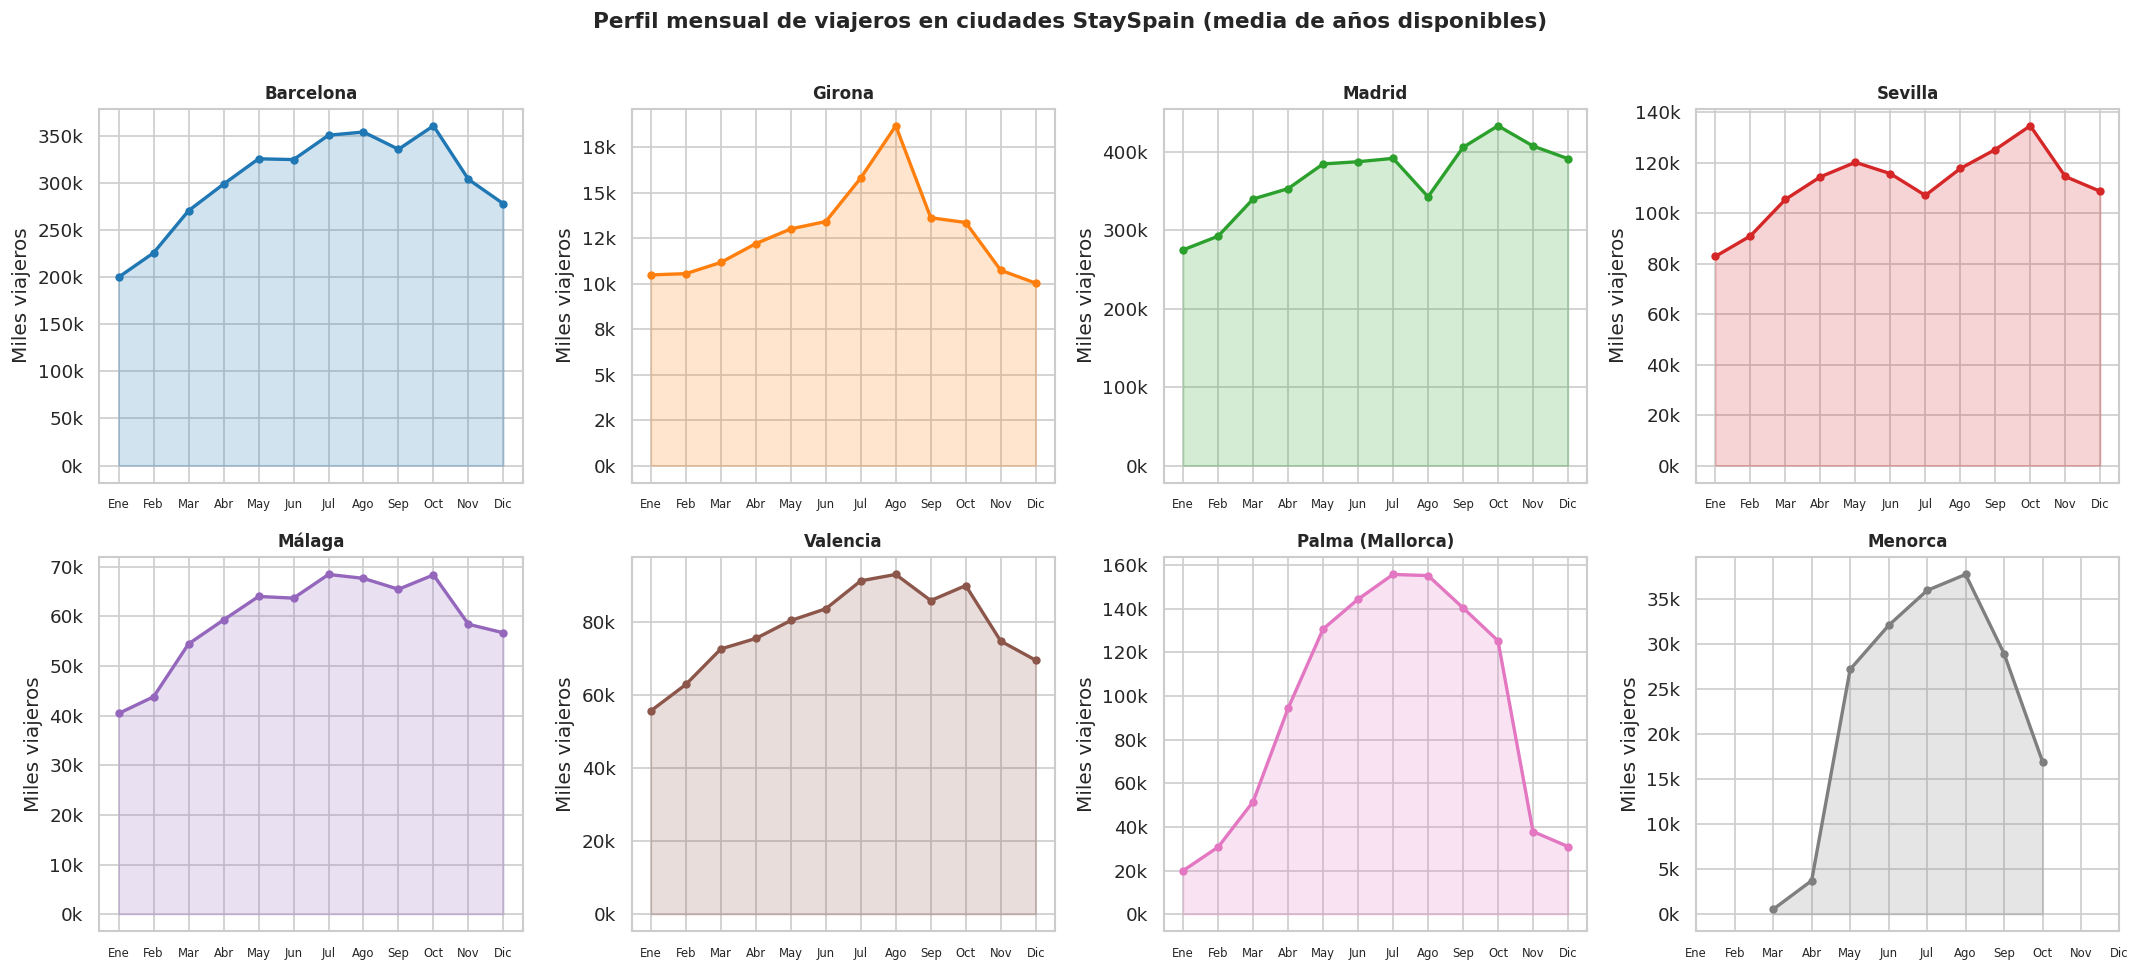

In [15]:
pal = sns.color_palette('tab10', n_colors=8)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flatten()

for i, ciudad in enumerate(CIUDADES_ORDEN):
    ax = axes[i]
    grp = perfil_ciu[perfil_ciu['ciudad_label']==ciudad].sort_values('mes')
    if grp.empty:
        ax.set_visible(False)
        continue
    x_vals = list(range(len(grp['mes'])))
    meses_labels = [MESES_ES[m] for m in grp['mes']]

    ax.fill_between(x_vals, grp['Total']/1e3, alpha=0.2, color=pal[i])
    ax.plot(x_vals, grp['Total']/1e3, marker='o', color=pal[i], linewidth=2, markersize=4)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(meses_labels, fontsize=7)
    ax.set_title(ciudad, fontweight='bold', fontsize=10)
    ax.set_ylabel('Miles viajeros')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fk'))

fig.suptitle('Perfil mensual de viajeros en ciudades StaySpain (media de años disponibles)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig4_ciudades_staystain.png', bbox_inches='tight')
plt.show()


**Interpretación técnica:** Los subgráficos muestran el número medio mensual de viajeros (en miles) para cada ciudad. Las curvas reflejan la forma característica de la estacionalidad de cada destino.

**Interpretación de negocio:**
- **Barcelona:** curva amplia y sostenida de mayo a noviembre, con el pico en octubre (360k). Es el destino con mayor volumen absoluto del portfolio. Muestra una estacionalidad moderada, con octubre superando incluso a los meses de verano estricto —reflejo del peso del turismo de negocios y de temporada alta extendida.
- **Girona:** curva moderada con pico en agosto (18,7k) y valores relativamente estables el resto del año. Con solo dos años de datos disponibles (2024–2025), los patrones deben interpretarse con cautela.
- **Madrid:** la curva más plana de las ocho ciudades. El pico es octubre (433k) y el mínimo enero (275k). No hay una temporada alta claramente diferenciada —la demanda se mantiene elevada todo el año—, lo que facilita una gestión estable.
- **Sevilla:** curva con un perfil de dos repuntes: uno en primavera (marzo–mayo) y otro en otoño (septiembre–octubre), que es el pico absoluto (135k). El verano estricto (julio) registra una bajada relativa, posiblemente por las altas temperaturas. Esto la diferencia del resto del portfolio.
- **Málaga:** curva con pico en julio (68,5k), con una temporada alta bien marcada de junio a octubre. A diferencia de Baleares, los meses de invierno mantienen niveles razonables (~40k), lo que refleja su combinación de sol y ciudad.
- **Valencia:** pico en agosto (93k) y una curva bastante equilibrada de mayo a octubre. El perfil es similar a Andalucía: temporada alta de verano prolongada con una caída gradual en otoño.
- **Palma (Mallorca):** curva pronunciada con pico en julio y agosto (155k ambos meses) y caída drástica en invierno (20k en enero). Patrón característico de sol y playa mediterráneo.
- **Menorca:** la curva más extrema de todas —prácticamente sin actividad de noviembre a febrero y con un pico concentrado en julio–agosto—. Con 37,7k viajeros en agosto frente a cifras mínimas en invierno, es el destino más estacional del portfolio.


---
## 5b. Mapa de calor — Concentración mensual por ciudad (visión comparada)

El mapa de calor normaliza los datos de cada ciudad al 100%, mostrando qué proporción del total anual  
de viajeros de esa ciudad se concentra en cada mes. Permite comparar los **patrones de distribución**  
entre ciudades con independencia de su volumen absoluto.


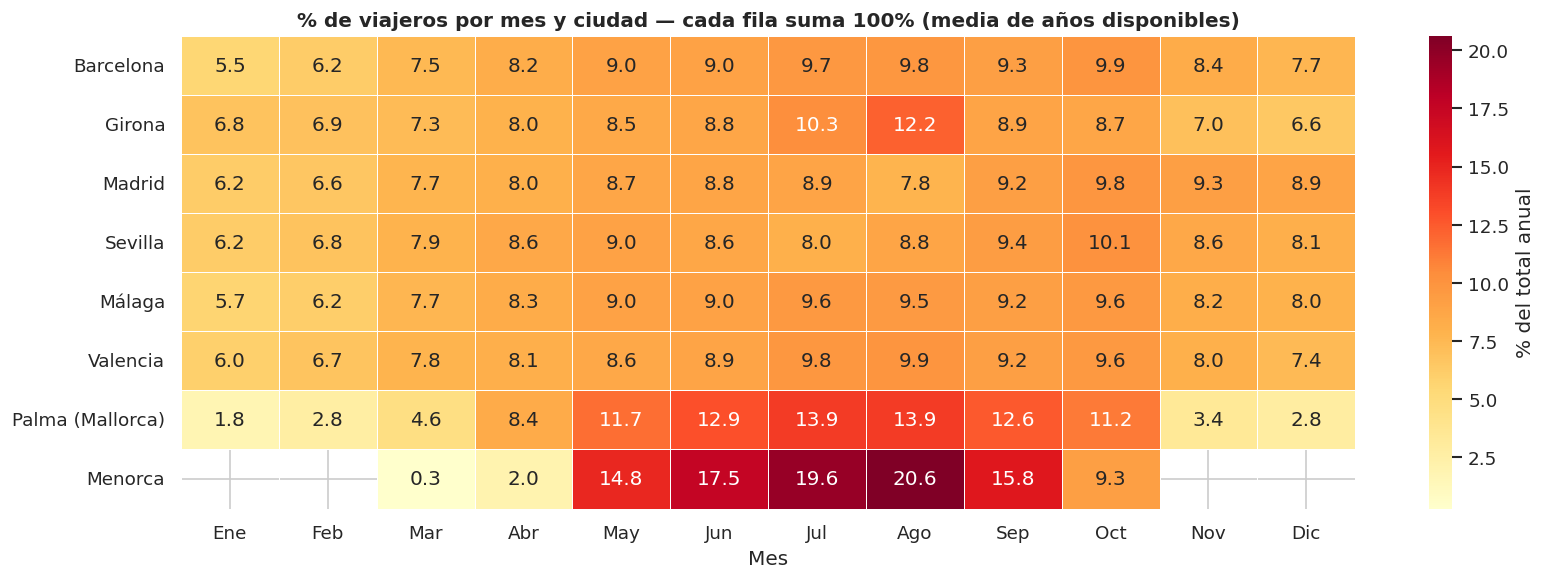

In [16]:
pivot_ciu = (perfil_ciu.pivot(index='ciudad_label', columns='mes', values='Total'))
pivot_ciu.columns = [MESES_ES[m] for m in pivot_ciu.columns]
pivot_ciu = pivot_ciu.reindex(CIUDADES_ORDEN)

# Normalizar por fila: % del total anual de cada ciudad
pivot_pct = pivot_ciu.div(pivot_ciu.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% del total anual'},
            mask=pivot_pct.isna())
ax.set_title('% de viajeros por mes y ciudad — cada fila suma 100% (media de años disponibles)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig5_heatmap_ciudades.png', bbox_inches='tight')
plt.show()


**Interpretación técnica:** Cada celda indica qué porcentaje de los viajeros anuales de esa ciudad llegan en ese mes. Las celdas en gris corresponden a meses sin datos (Menorca en enero, febrero, noviembre y diciembre, ya que los establecimientos están cerrados). Cada fila suma 100%.

**Interpretación de negocio:**

**Destinos altamente concentrados en verano:**
- **Menorca** concentra el 19,6% de sus viajeros en julio y el 20,6% en agosto (sumando el 40,2% del año en solo dos meses). Si se incluye junio y septiembre, el cuatrimestre jun–sep acumula más del 73% del total anual. Es el destino más dependiente del verano del portfolio.
- **Palma (Mallorca)** tiene junio, julio y agosto con porcentajes similares (~13–14% cada uno). El cuatrimestre may–ago concentra más del 51% del año.

**Destinos con distribución equilibrada:**
- **Madrid** es el más equilibrado: ningún mes supera el 9,8% (octubre) y ninguno baja del 6,2% (enero), lo que supone una diferencia de apenas 3,6 puntos entre el mes más alto y el más bajo.
- **Sevilla** también es muy equilibrada: su máximo es octubre (10,1%) y su mínimo enero (6,2%). Destaca además la bajada relativa de julio (8,0%) frente a otros meses, lo que refleja el impacto del calor extremo sevillano en los flujos estivales.
- **Málaga, Valencia y Barcelona** muestran un perfil intermedio: pico moderado en julio–agosto–octubre (9–10%) con mínimos en enero–febrero (5–6%).

**Sobre los meses más "fríos":**
- Enero y febrero son los meses con menor porcentaje en casi todas las ciudades, pero con matices importantes: en **Palma** (1,8% y 2,8%) y **Menorca** (sin datos / 0,3% en marzo) la caída invernal es drástica, mientras que en **Madrid y Sevilla** enero sigue representando más del 6% del total anual —una cifra nada despreciable para la operativa—.


---
## 6. Perfil de residencia por mes — ¿Los turistas nacionales e internacionales viajan en las mismas épocas?

Comparamos la estacionalidad de viajeros **residentes en España** vs. **residentes en el extranjero** a nivel nacional.


In [17]:
res_por_mes = df_com[
    (df_com['nombre_comunidad'].isna()) &
    (df_com['Viajeros y pernoctaciones'] == 'Viajero') &
    (df_com['Residencia: Nivel 2'].notna())
].copy()

res_pivot = (res_por_mes.groupby(['Residencia: Nivel 2','mes'])['Total']
             .mean().reset_index())
res_pivot['mes_label'] = res_pivot['mes'].map(MESES_ES)

res_tabla = res_pivot.pivot(index='mes', columns='Residencia: Nivel 2', values='Total')
res_tabla.index = [MESES_ES[m] for m in res_tabla.index]
res_tabla['Ratio Ext/Nac'] = (res_tabla['Residentes en el Extranjero'] /
                               res_tabla['Residentes en España'])
res_tabla['Predomina'] = res_tabla['Ratio Ext/Nac'].apply(
    lambda x: 'Extranjero' if x > 1 else 'Nacional')

display(res_tabla.style.format({
    'Residentes en España': '{:,.0f}',
    'Residentes en el Extranjero': '{:,.0f}',
    'Ratio Ext/Nac': '{:.2f}'
}))


Residencia: Nivel 2,Residentes en España,Residentes en el Extranjero,Ratio Ext/Nac,Predomina
Ene,"2,406,506","1,933,104",0.80,Nacional
Feb,"2,864,732","2,202,300",0.77,Nacional
Mar,"3,416,061","2,850,887",0.83,Nacional
Abr,"4,010,232","3,971,940",0.99,Nacional
May,"4,333,464","5,161,912",1.19,Extranjero
Jun,"5,183,612","5,281,171",1.02,Extranjero
Jul,"5,891,753","5,959,149",1.01,Extranjero
Ago,"6,523,181","6,280,024",0.96,Nacional
Sep,"5,066,024","5,881,718",1.16,Extranjero
Oct,"4,601,202","5,411,705",1.18,Extranjero


**Interpretación técnica:** La columna *Ratio Ext/Nac* indica cuántos viajeros extranjeros llegan por cada viajero nacional. Un ratio > 1 indica que los turistas internacionales superan a los nacionales en ese mes. La columna *Predomina* resume quién domina en cada período.

**Interpretación de negocio:** El turismo nacional predomina en los meses de invierno (noviembre–marzo), mientras que el internacional toma la delantera en los meses de primavera y verano. Esta alternancia es una oportunidad para StaySpain: las campañas de comunicación y las acciones de captación pueden adaptarse al perfil dominante en cada período del año —campañas en castellano y orientadas a escapadas cortas en invierno; comunicación en inglés, francés o alemán y paquetes de estancias más largas en verano.


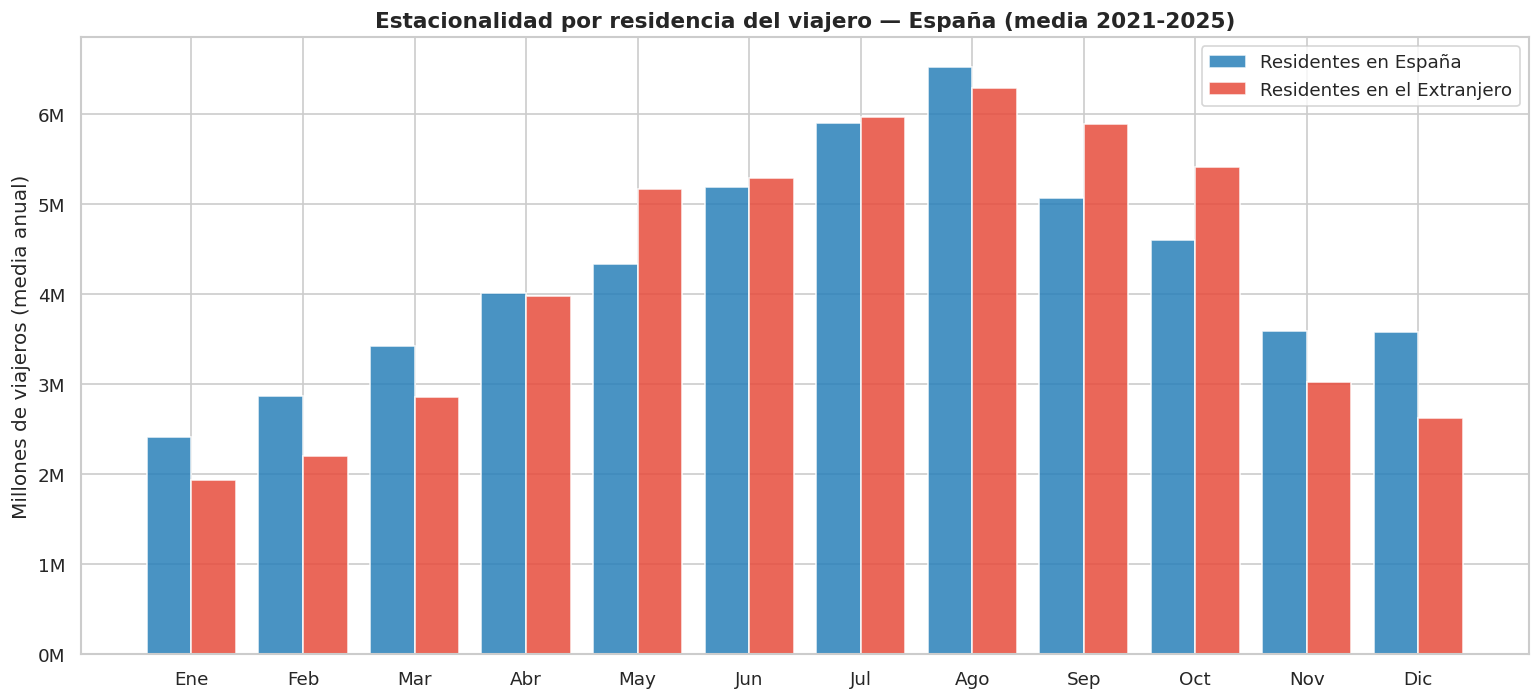

In [18]:
fig, ax = plt.subplots(figsize=(13, 6))

res_nac = res_pivot[res_pivot['Residencia: Nivel 2']=='Residentes en España'].sort_values('mes')
res_ext = res_pivot[res_pivot['Residencia: Nivel 2']=='Residentes en el Extranjero'].sort_values('mes')

x = range(12)
width = 0.4
ax.bar([i - width/2 for i in x], res_nac['Total']/1e6, width,
       label='Residentes en España', color='#2980b9', alpha=0.85)
ax.bar([i + width/2 for i in x], res_ext['Total']/1e6, width,
       label='Residentes en el Extranjero', color='#e74c3c', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(list(MESES_ES.values()))
ax.set_ylabel('Millones de viajeros (media anual)')
ax.set_title('Estacionalidad por residencia del viajero — España (media 2021-2025)',
             fontweight='bold', fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fM'))
plt.tight_layout()
plt.savefig('fig6_residencia_por_mes.png', bbox_inches='tight')
plt.show()


**Interpretación técnica:** El gráfico de barras dobles compara mes a mes el volumen de viajeros nacionales (azul) e internacionales (rojo). Se observa que las barras rojas superan a las azules en los meses de mayor actividad turística (abril–septiembre), mientras que las azules dominan en los meses de invierno (noviembre–febrero).

**Interpretación de negocio:** El turismo internacional es claramente más estacional: tiene picos más pronunciados en verano y caídas más acusadas en invierno. El turismo nacional actúa como "colchón" que mantiene un nivel mínimo de actividad durante todo el año. Para StaySpain, esta distribución refuerza la idea de que captar turismo nacional en los meses de menor demanda internacional es una palanca clave para suavizar la estacionalidad de los alojamientos.


---
## 6b. Nacionales vs. extranjeros en las ciudades StaySpain

¿El origen del viajero cambia el patrón mensual a nivel de ciudad?


In [19]:
# Tabla resumen: ratio total anual extranjero/nacional por ciudad
resumen_res = []
for ciudad in CIUDADES_ORDEN:
    sub = df_ss_viaj[df_ss_viaj['ciudad_label']==ciudad]
    nac = sub[sub['Residencia']=='Residentes en España']['Total'].sum()
    ext = sub[sub['Residencia']=='Residentes en el Extranjero']['Total'].sum()
    ratio = ext/nac if nac > 0 else float('inf')
    # meses donde ext > nac
    nac_m = sub[sub['Residencia']=='Residentes en España'].groupby('mes')['Total'].mean()
    ext_m = sub[sub['Residencia']=='Residentes en el Extranjero'].groupby('mes')['Total'].mean()
    both = pd.DataFrame({'nac':nac_m,'ext':ext_m}).dropna()
    meses_ext = [MESES_ES[m] for m in both[both['ext']>both['nac']].index.tolist()]
    resumen_res.append({
        'Ciudad': ciudad,
        'Viaj. Nacionales': f"{nac/1e3:.0f}k",
        'Viaj. Extranjeros': f"{ext/1e3:.0f}k",
        'Ratio Ext/Nac': f"{ratio:.2f}",
        'Meses con predominio extranjero': ', '.join(meses_ext) if meses_ext else 'Ninguno',
    })
display(pd.DataFrame(resumen_res))


,Ciudad,Viaj. Nacionales,Viaj. Extranjeros,Ratio Ext/Nac,Meses con predominio extranjero
0,Barcelona,7198k,29077k,4.04,"Ene, Feb, Mar, Abr, May, Jun, Jul, Ago, Sep, O..."
1,Girona,226k,386k,1.70,"Feb, Mar, Abr, May, Jun, Jul, Ago, Sep, Oct"
2,Madrid,20691k,23326k,1.13,"Mar, Abr, May, Jun, Jul, Ago, Sep, Oct"
3,Sevilla,6102k,7281k,1.19,"Mar, Abr, May, Jun, Jul, Ago, Sep, Oct, Nov"
4,Málaga,2975k,4133k,1.39,"Ene, Feb, Mar, Abr, May, Jun, Jul, Ago, Sep, O..."
5,Valencia,4436k,4920k,1.11,"Abr, May, Jun, Jul, Ago, Sep, Oct"
6,Palma (Mallorca),1637k,9531k,5.82,"Ene, Feb, Mar, Abr, May, Jun, Jul, Ago, Sep, O..."
7,Menorca,170k,562k,3.31,"Abr, May, Jun, Jul, Ago, Sep, Oct"


**Interpretación técnica:** La tabla resume la relación entre turistas nacionales e internacionales para cada ciudad StaySpain. El ratio Ext/Nac indica cuántos turistas extranjeros llegan por cada turista nacional. La última columna muestra en qué meses los extranjeros superan a los nacionales.

**Interpretación de negocio:**
- **Barcelona y Palma (Mallorca)** son los destinos más internacionales del portfolio (ratios de 4,04 y 5,82 respectivamente). Los turistas extranjeros superan a los nacionales en **todos los meses del año**, lo que significa que estas ciudades dependen estructuralmente del turismo internacional y son más vulnerables a disrupciones externas (crisis europeas, tipos de cambio, conflictos).
- **Málaga** también tiene predominio extranjero todo el año (ratio 1,39), aunque con menor intensidad que Barcelona y Palma.
- **Menorca y Girona** tienen predominio extranjero de abril a octubre —la práctica totalidad de su temporada activa—, pero los nacionales se recuperan fuera de temporada.
- **Madrid, Sevilla y Valencia** tienen ratios cercanos a 1 (entre 1,11 y 1,19), con predominio extranjero solo en los meses de primavera y verano, y nacionales dominando en otoño e invierno. Estas ciudades tienen el perfil más diversificado en cuanto a origen del viajero.


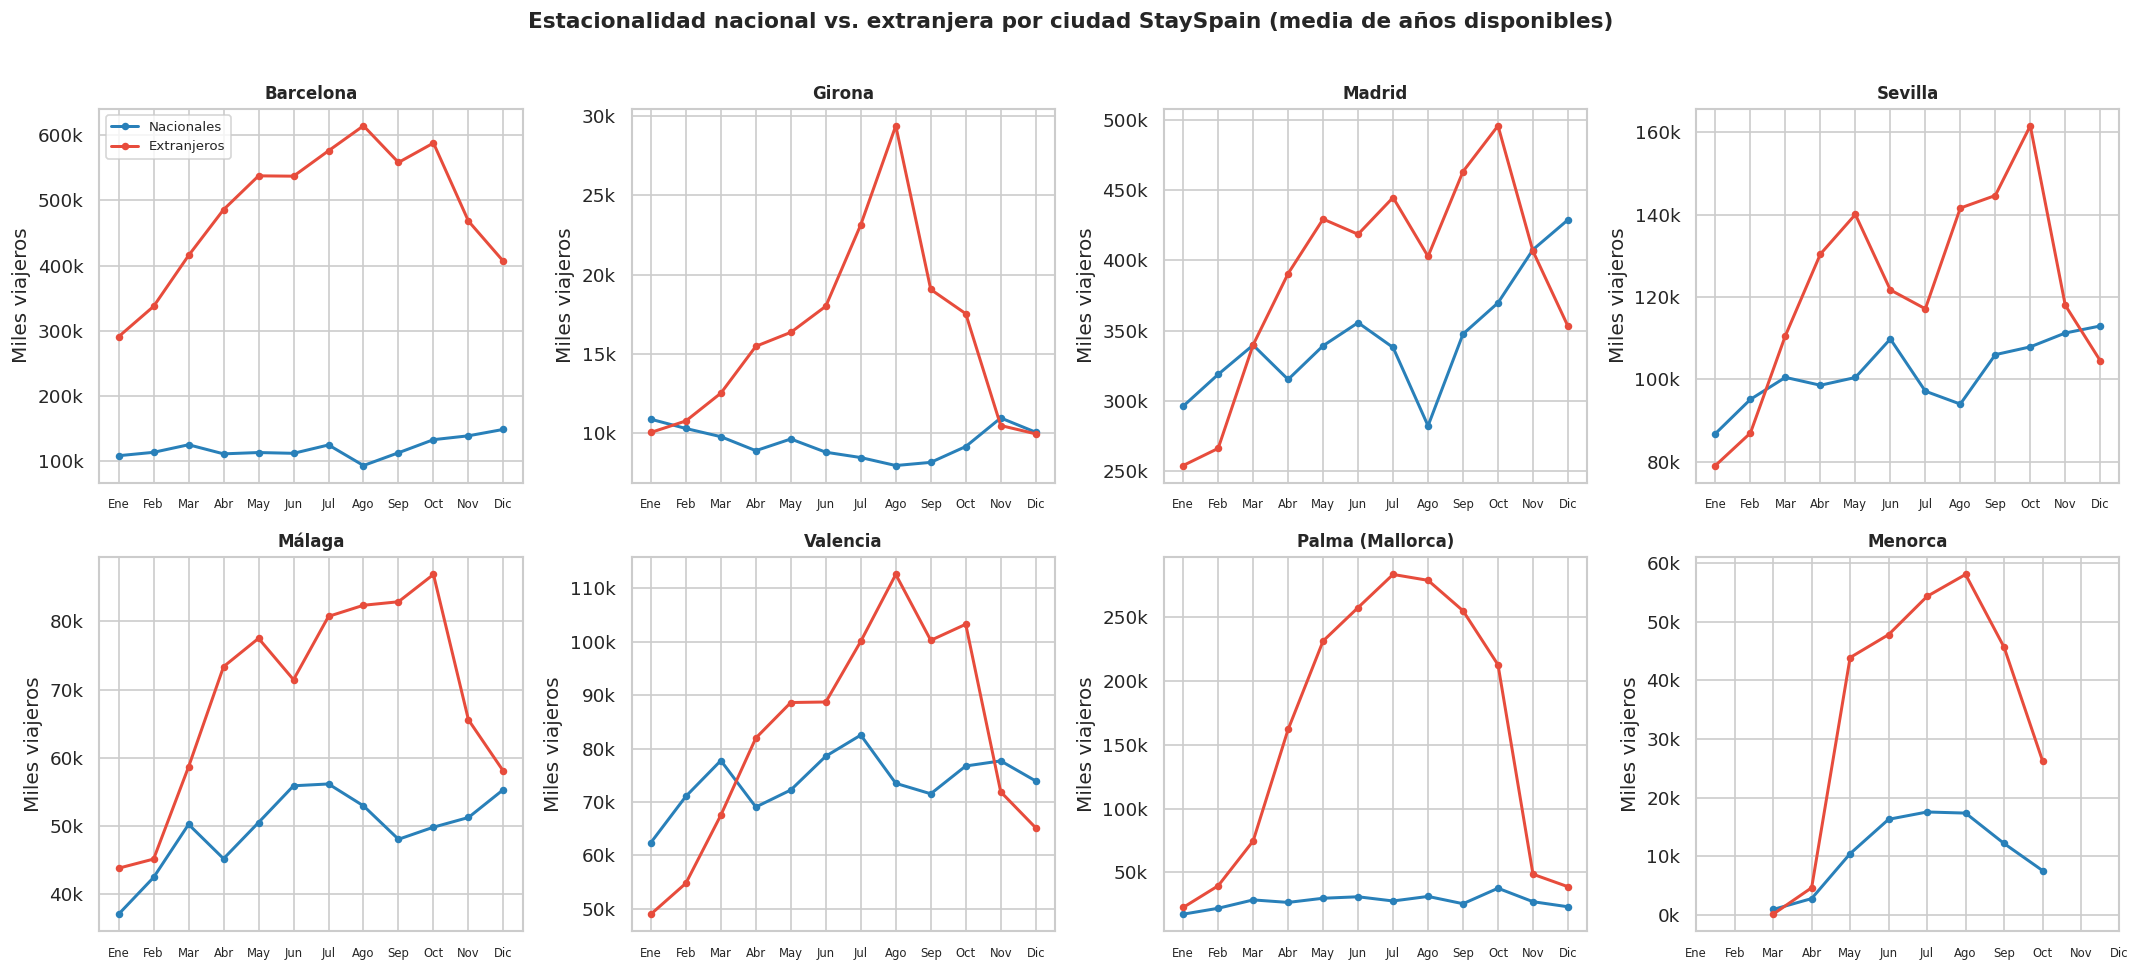

In [20]:
df_ss_res = df_ss[df_ss['Viajeros y pernoctaciones'] == 'Viajero'].copy()

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flatten()
pal2 = ['#2980b9', '#e74c3c']

for i, ciudad in enumerate(CIUDADES_ORDEN):
    ax = axes[i]
    sub = df_ss_res[df_ss_res['ciudad_label']==ciudad]
    if sub.empty:
        ax.set_visible(False)
        continue
    for j, (res, lbl) in enumerate([('Residentes en España','Nacionales'),
                                      ('Residentes en el Extranjero','Extranjeros')]):
        grp = sub[sub['Residencia']==res].groupby('mes')['Total'].mean().reset_index().sort_values('mes')
        if grp.empty:
            continue
        x_v = list(range(len(grp)))
        ax.plot(x_v, grp['Total']/1e3, marker='o', color=pal2[j],
                linewidth=1.8, markersize=3.5, label=lbl)
        ax.set_xticks(x_v)
        ax.set_xticklabels([MESES_ES[m] for m in grp['mes']], fontsize=7)
    ax.set_title(ciudad, fontweight='bold', fontsize=10)
    ax.set_ylabel('Miles viajeros')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fk'))
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Estacionalidad nacional vs. extranjera por ciudad StaySpain (media de años disponibles)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig7_ciudades_residencia.png', bbox_inches='tight')
plt.show()


**Interpretación técnica:** Para cada ciudad, la curva azul representa los viajeros nacionales y la roja los internacionales. Cuando la línea roja está por encima de la azul, los extranjeros superan a los nacionales en ese mes; cuando se invierten, los nacionales predominan.

**Interpretación de negocio:**
- **Barcelona:** la línea roja (extranjeros) está siempre muy por encima de la azul (nacionales) durante todos los meses del año, con picos en julio–octubre. La brecha es especialmente amplia en verano. Barcelona es un destino donde el turismo nacional tiene un papel claramente secundario.
- **Madrid:** ambas curvas están muy próximas durante todo el año, con la línea roja ligeramente por encima en verano (marzo–octubre) y la azul dominando en otoño e invierno (noviembre–febrero). Es el destino más equilibrado entre los dos segmentos.
- **Sevilla:** similar a Madrid en cuanto a equilibrio, pero con un patrón bimodal propio: los picos de ambas curvas se producen en primavera (abril) y otoño (octubre), y en julio hay una bajada relativa de ambas, algo atípico respecto al resto de ciudades.
- **Málaga:** extranjeros por encima durante todo el año. La diferencia entre curvas es más moderada que en Barcelona o Palma, y ambas siguen una forma similar con pico en julio.
- **Valencia:** las curvas se cruzan claramente: los extranjeros dominan de abril a octubre, y los nacionales toman la delantera de noviembre a marzo.
- **Palma (Mallorca):** la brecha entre extranjeros (rojo) y nacionales (azul) es la mayor de todo el portfolio, con una diferencia de hasta 5 a 1 en temporada alta. La línea azul es prácticamente plana durante todo el año (~2–4k mensuales), mientras la roja tiene un pico pronunciado en julio–agosto.
- **Girona y Menorca:** en ambos casos la curva de extranjeros domina claramente en temporada alta, mientras que fuera de temporada los volúmenes son muy bajos en ambos segmentos.


---
## 7. Tendencia de crecimiento interanual por ciudad StaySpain

¿Han crecido todas las ciudades por igual entre 2021 y 2025?

> **Nota metodológica:** Girona y Menorca no tienen valores numéricos en el CSV para 2021–2023  
> (el INE no publicó datos para esas ciudades en ese período). Por este motivo se excluyen del  
> cálculo de crecimiento 2021→2024. El análisis de crecimiento se realiza sobre las 6 ciudades  
> con datos numéricos disponibles desde 2021.


In [21]:
viaj_anual_ciu = (df_ss_viaj.groupby(['ciudad_label','año'])['Total']
                  .sum().reset_index())
pivot_ciu_anio = viaj_anual_ciu.pivot(index='año', columns='ciudad_label', values='Total')

# Ciudades con datos numéricos reales en 2021
ciudades_2021     = [c for c in CIUDADES_ORDEN if pivot_ciu_anio.loc[2021, c] > 0]
ciudades_sin_2021 = [c for c in CIUDADES_ORDEN if c not in ciudades_2021]

print(f"Con datos desde 2021: {ciudades_2021}")
print(f"Sin datos en 2021-2023 (INE no publicó): {ciudades_sin_2021}")

tabla_crecim = pd.DataFrame({
    'Ciudad'              : ciudades_2021,
    'Viajeros 2021'       : ["{:,.0f}k".format(pivot_ciu_anio.loc[2021, c]/1e3) for c in ciudades_2021],
    'Viajeros 2024'       : ["{:,.0f}k".format(pivot_ciu_anio.loc[2024, c]/1e3) for c in ciudades_2021],
    'Viajeros 2025'       : ["{:,.0f}k".format(pivot_ciu_anio.loc[2025, c]/1e3) for c in ciudades_2021],
    'Crecim. 2021-2024 (%)': ["{:+.1f}%".format(
        (pivot_ciu_anio.loc[2024,c]-pivot_ciu_anio.loc[2021,c])/pivot_ciu_anio.loc[2021,c]*100)
        for c in ciudades_2021],
})
tabla_crecim = tabla_crecim.sort_values('Crecim. 2021-2024 (%)', ascending=False)
display(tabla_crecim.reset_index(drop=True))


Con datos desde 2021: ['Barcelona', 'Madrid', 'Sevilla', 'Málaga', 'Valencia', 'Palma (Mallorca)']
Sin datos en 2021-2023 (INE no publicó): ['Girona', 'Menorca']


,Ciudad,Viajeros 2021,Viajeros 2024,Viajeros 2025,Crecim. 2021-2024 (%)
0,Málaga,824k,"1,616k","1,834k",+96.1%
1,Valencia,"1,165k","2,060k","2,128k",+76.8%
2,Barcelona,"3,265k","8,404k","8,991k",+157.4%
3,Madrid,"4,651k","10,381k","10,415k",+123.2%
4,Palma (Mallorca),"1,172k","2,589k","2,618k",+120.8%
5,Sevilla,"1,464k","3,128k","3,127k",+113.6%


**Interpretación técnica:** La tabla muestra el volumen de viajeros en 2021, 2024 y 2025 para las seis ciudades con valores numéricos disponibles desde 2021. Girona y Menorca se excluyen porque el INE no publicó datos para esas ciudades en 2021–2023 — sus filas existen en el CSV pero sin valor en la columna `Total`. El crecimiento entre 2021 y 2024 refleja tanto la recuperación post-COVID como el crecimiento real del mercado.

**Interpretación de negocio:** Todas las ciudades con datos desde 2021 muestran crecimientos positivos, confirmando la expansión del turismo hotelero. Barcelona y Madrid lideran en volumen absoluto —superando los 8 y 10 millones de viajeros anuales en 2025 respectivamente— pero son los destinos más maduros, con crecimientos porcentuales más moderados. Sevilla y Málaga muestran los crecimientos más dinámicos del período (más del doble entre 2021 y 2025), lo que las posiciona como los destinos con mayor potencial de expansión del portfolio StaySpain.


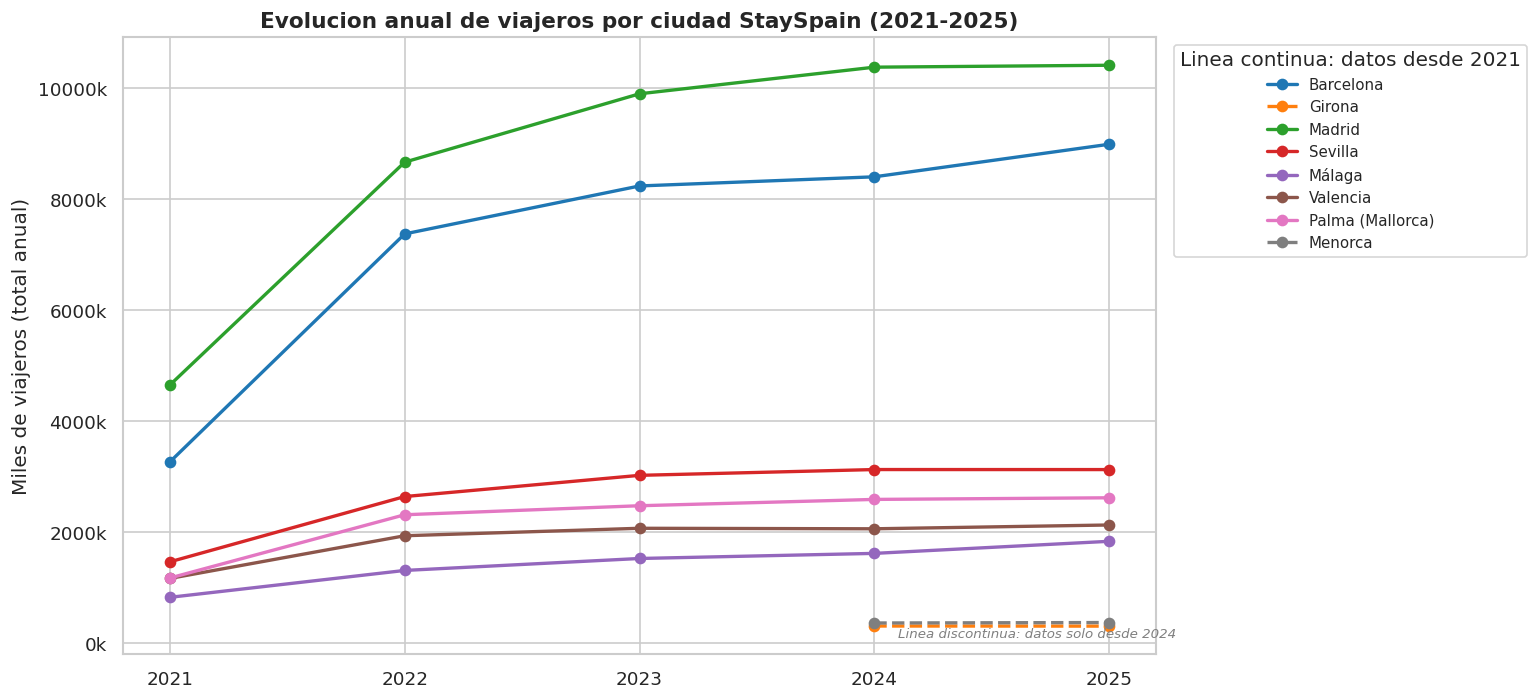

In [22]:
fig, ax = plt.subplots(figsize=(13, 6))
colors_line = sns.color_palette('tab10', n_colors=8)

# Mostrar todas las ciudades, marcando con linea discontinua las que empiezan desde 2024
for i, ciudad in enumerate(CIUDADES_ORDEN):
    serie = pivot_ciu_anio[ciudad].dropna()
    serie = serie[serie > 0]
    if serie.empty:
        continue
    estilo = '--' if ciudad in ciudades_sin_2021 else '-'
    ax.plot(serie.index, serie/1e3,
            marker='o', label=ciudad,
            color=colors_line[i], linewidth=2, linestyle=estilo)

ax.set_xticks(sorted(pivot_ciu_anio.index))
ax.set_title('Evolucion anual de viajeros por ciudad StaySpain (2021-2025)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Miles de viajeros (total anual)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
          title='Linea continua: datos desde 2021')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fk'))
ax.annotate('Linea discontinua: datos solo desde 2024', xy=(2024.1, 100),
            fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('fig8_tendencia_ciudades.png', bbox_inches='tight')
plt.show()


**Interpretación técnica:** El gráfico muestra la evolución del total anual de viajeros por ciudad entre 2021 y 2025. Las líneas continuas corresponden a las seis ciudades con datos desde 2021; las líneas discontinuas (Girona y Menorca) aparecen solo desde 2024, que es cuando el INE comenzó a publicar datos numéricos para esas ciudades. La pendiente de cada curva indica la velocidad de crecimiento.

**Interpretación de negocio:**
- **Madrid y Barcelona** dominan en volumen (10.415k y 8.991k en 2025) con una trayectoria constante y sostenida. Son los pilares del portfolio StaySpain.
- **Sevilla** ha más que duplicado su volumen entre 2021 y 2025 (de 1.464k a 3.127k), con la pendiente más pronunciada de las ciudades medianas. Es el destino con mayor dinamismo.
- **Málaga** también ha duplicado su volumen (de 824k a 1.834k) y mantiene una tendencia ascendente en 2025.
- **Palma (Mallorca)** ha crecido considerablemente (de 1.172k a 2.618k) pero su curva tiende a estabilizarse en 2024–2025.
- **Valencia** presenta el crecimiento más moderado y su curva se aplana en 2024–2025, señal de mayor madurez del mercado.
- **Girona y Menorca** aparecen desde 2024 con volúmenes modestos, pendientes de que el INE publique series históricas completas para poder evaluar su evolución.


---
## 8. Conclusiones / Hallazgos / Recomendaciones

### Hallazgos principales

**H1 — La estacionalidad es pronunciada pero no extrema a nivel nacional**  
A nivel nacional, el período julio–octubre concentra aproximadamente el 40% de los viajeros anuales, con agosto como mes pico [Sección 2, Fig. 1]. Sin embargo, ningún mes supera el 10,5% del total, lo que indica que la estacionalidad tiene un carácter moderado a escala país. La distribución es asimétrica: la caída hacia el invierno es gradual, sin desplomes bruscos.

**H2 — Crecimiento sostenido 2021–2025, con mayor dinamismo en primavera y otoño**  
Todos los meses del año han registrado más viajeros en 2024–2025 que en 2021, confirmando la recuperación post-COVID completada [Sección 3, Fig. 2]. Los meses de abril–mayo y octubre han crecido a mayor velocidad en los últimos años, lo que señala que la demanda está tendiendo a distribuirse más allá del verano estricto.

**H3 — Heterogeneidad extrema en la estacionalidad entre ciudades StaySpain**  
El análisis de ratios pico/valle [Sección 5, Tabla y Fig. 5] revela perfiles muy distintos dentro del mismo portfolio:
- **Menorca** (69,8x) y **Palma** (7,8x): destinos con concentración extrema en verano.
- **Madrid y Sevilla** (1,6x ambas): los más equilibrados, con demanda sostenida durante todo el año.
- **Barcelona, Málaga y Valencia** (1,7x–1,8x): estacionalidad moderada con temporada alta extendida.

**H4 — Illes Balears es la CCAA más estacional del portfolio por una diferencia muy amplia**  
El ratio pico/valle de Illes Balears es de 34x, frente a 3,2x de Cataluña o 1,6x de Madrid [Sección 4, Tabla y Fig. 3]. En Balears, el valle invernal (enero: 50.000 viajeros) es 34 veces menor que el pico estival (agosto: 1,85 millones). Esta diferencia no es gradual: la curva es prácticamente plana en invierno y tiene una joroba muy pronunciada en verano, lo que la distingue cualitativamente del resto de CCAA.

**H5 — El turismo internacional es más estacional que el nacional, y domina en el 62% de las ciudades StaySpain durante todo el año**  
A nivel nacional, los extranjeros superan a los nacionales entre abril y septiembre [Sección 6, Fig. 6]. En Barcelona, Palma y Málaga los extranjeros predominan durante los doce meses del año [Sección 6b, Tabla]. En Madrid, Sevilla y Valencia los perfiles son más equilibrados, con los nacionales recuperando el predominio en otoño e invierno.

**H6 — Sevilla y Málaga son los destinos con mayor crecimiento relativo en el período 2021–2025**  
Ambas ciudades han duplicado su volumen de viajeros entre 2021 y 2025, con tasas de crecimiento superiores a las de Barcelona y Madrid [Sección 7, Fig. 8]. Madrid y Barcelona lideran en volumen absoluto pero muestran un crecimiento más moderado, coherente con mercados más maduros.

---

### Recomendaciones de negocio para StaySpain

**R1 — Estrategia diferenciada según el perfil estacional de cada destino**  
La gestión de precios y disponibilidad debe adaptarse al ratio de estacionalidad de cada ciudad:
- **Menorca y Palma**: maximización agresiva del precio en temporada alta (junio–septiembre) y contratos flexibles o cierres parciales en invierno.
- **Madrid y Sevilla**: estrategia de precio estable y ocupación continua; palanca de ingresos a lo largo de todo el año.
- **Barcelona, Málaga y Valencia**: precios dinámicos con temporada alta extendida (mayo–octubre) y activaciones puntuales en temporada baja.

**R2 — Aprovechar el crecimiento de los meses de primavera y otoño**  
El análisis interanual [H2] muestra que abril, mayo y octubre crecen por encima de la media nacional. StaySpain puede anticiparse reforzando visibilidad y promoción en esas fechas, con propuestas específicas: turismo cultural, escapadas de fin de semana, festivales o turismo gastronómico.

**R3 — Diversificar el mix de viajeros nacionales/internacionales en destinos con alta dependencia exterior**  
Barcelona, Palma y Málaga dependen de los turistas extranjeros incluso en invierno [H5]. Esta dependencia las expone a riesgos externos (crisis en mercados emisores, variaciones de tipo de cambio). Diseñar campañas específicas en español orientadas al viajero nacional para los meses de menor actividad internacional puede reducir este riesgo y mejorar la ocupación invernal.

**R4 — Sevilla como destino estratégico de expansión del portfolio**  
Su perfil bimodal (picos en primavera y otoño, bajada relativa en julio) y su fuerte crecimiento 2021–2025 [H6] la posicionan como un destino ideal para ampliar el número de alojamientos activos en StaySpain. Además, su equilibrio entre turismo nacional e internacional le da resiliencia.

**R5 — Gestión activa de Menorca más allá del verano**  
Aunque la estacionalidad de Menorca es estructural (ligada al modelo de turismo de sol y playa de la isla), hay margen para extender la temporada activa hacia mayo y octubre, donde ya se observan porcentajes no despreciables del total anual [Sección 5b, Fig. 5]. Iniciativas de turismo de naturaleza, senderismo o turismo náutico fuera del verano podrían complementar la oferta de los alojamientos.

**R6 — Integración con los análisis de procedencia y pernoctaciones (puesta en común)**  
Las conclusiones de este análisis deben complementarse con:
- El análisis de **procedencia** (¿de dónde vienen?): para identificar qué mercados emisores alimentan los picos estacionales de cada ciudad y priorizar acciones de marketing.
- El análisis de **pernoctaciones** (¿cuánto se quedan?): para saber si los meses de alta afluencia también implican estancias más largas, o si la clave está en la rotación de viajeros.

La integración de los tres análisis permitirá a StaySpain formular una estrategia de negocio completa y respaldada por datos sobre cómo ajustar su oferta de alojamiento a la demanda real del viajero en cada ciudad y en cada época del año.
